## 22.5) Base de dados cartão de crédito - 1 atributo

- Fonte: https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

- se pagará o próximo pagamento com base no histórco de pagamentos dos 6 meses anteriores.

- encontrar algum tipo de padrão entre o limite do cartão de crédito que o cliente possui e o valor total das últimas faturas do cartão. 

Associated Tasks

Classification

### Additional Information

This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods. From the perspective of risk management, the result of predictive accuracy of the estimated probability of default will be more valuable than the binary result of classification - credible or not credible clients. Because the real probability of default is unknown, this study presented the novel Sorting Smoothing Method to estimate the real probability of default. With the real probability of default as the response variable (Y), and the predictive probability of default as the independent variable (X), the simple linear regression result (Y = A + BX) shows that the forecasting model produced by artificial neural network has the highest coefficient of determination; its regression intercept (A) is close to zero, and regression coefficient (B) to one. Therefore, among the six data mining techniques, artificial neural network is the only one that can accurately estimate the real probability of default.



### Additional Variable Information

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:

X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.

X2: Gender (1 = male; 2 = female).

X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).

X4: Marital status (1 = married; 2 = single; 3 = others).

X5: Age (year).

X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 

X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

In [1]:
import pandas as pd
base_cartao = pd.read_csv('credit_card_clients.csv', header = 1)
base_cartao

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [2]:
base_cartao.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [3]:
# LIMIT_BAL limite do cartão de crédito dos clientes 

In [5]:
# 'PAY_0','PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' pagamentos anteriores do cartão de crédito 

In [6]:
# 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',total da fatura do cartão de crédito nos seis meses

In [7]:
# 'PAY_AMT1',  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6' o quanto o cliente pagou a fatura
# para ver se pagou certinho tem que subitrair o BILL_AMT do PAY_AMT

In [9]:
# que indica se o cliente vai ou não pagar a próxima fatura    'default payment next month'

1  o cliente não pagou

0  o cliente pagou

para ver se o cliente pagará ou não o banco, com base na classificação. 

In [10]:
base_cartao['BILL_TOTAL'] = base_cartao['BILL_AMT1'] + base_cartao['BILL_AMT2'] + base_cartao['BILL_AMT3'] + base_cartao['BILL_AMT4'] + base_cartao['BILL_AMT5'] + base_cartao['BILL_AMT6']

In [11]:
base_cartao.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,BILL_TOTAL
29995,29996,220000,1,3,1,39,0,0,0,0,...,31237,15980,8500,20000,5003,3047,5000,1000,0,725349
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,5190,0,1837,3526,8998,129,0,0,0,21182
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20582,19357,0,0,22000,4200,2000,3100,1,70496
29998,29999,80000,1,3,1,41,1,-1,0,0,...,11855,48944,85900,3409,1178,1926,52964,1804,1,266611
29999,30000,50000,1,2,1,46,0,0,0,0,...,32428,15313,2078,1800,1430,1000,1000,1000,1,230874


In [16]:
display(base_cartao.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,BILL_TOTAL
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,689,0,0,0,0,1,7704
1,2,120000,2,2,2,26,-1,2,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,17077
2,3,90000,2,2,2,34,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,101653
3,4,50000,2,2,1,37,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,231334
4,5,50000,1,2,1,57,-1,0,-1,0,...,19146,19131,2000,36681,10000,9000,689,679,0,109339


In [17]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(base_cartao.head())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  \
0     -2     -2       3913       3102        689          0          0   
1      0      2       2682       1725       2682       3272       3455   
2      0      0      29239      14027      13559      14331      14948   
3      0      0      46990      48233      49291      28314      28959   
4      0      0       8617       5670      35835      20940      19146   

   BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  \
0   

In [18]:
base_cartao.iloc[:, [1, 25]].columns # ver as colunas de interesse

Index(['LIMIT_BAL', 'BILL_TOTAL'], dtype='object')

In [20]:
X_cartao = base_cartao.iloc[:, [1, 25]].values  # limite do cartão e a fatura total gasta no cartão
X_cartao

array([[ 20000,   7704],
       [120000,  17077],
       [ 90000, 101653],
       ...,
       [ 30000,  70496],
       [ 80000, 266611],
       [ 50000, 230874]])

In [22]:
# padronizar os dados
from sklearn.preprocessing import StandardScaler
scaler_cartao = StandardScaler()
X_cartao = scaler_cartao.fit_transform(X_cartao)

In [23]:
X_cartao

array([[-1.13672015, -0.69069198],
       [-0.3659805 , -0.66599747],
       [-0.59720239, -0.44316987],
       ...,
       [-1.05964618, -0.52525745],
       [-0.67427636, -0.00856436],
       [-0.90549825, -0.10271861]])

In [25]:
# diferença no limite do cartão e no gasto total do cartão;

# para deixar os dados todos na mesma escala, pois há diferença no limite e no gasto

##### antes de fazer o agrupamento aplicamos a técnica do WCSS

### O WCSS (Within-Cluster Sum of Squares) é a métrica usada no K-Means para medir a variação interna dos clusters.


WCSS método do cotovelo para determinar o número de cluster

In [31]:
import math
# Use a função sqrt() da biblioteca math
resultado_num_cluster = math.sqrt(len(X_cartao)/2)
print(resultado_num_cluster) # ideal a quantidade de cluster

122.47448713915891


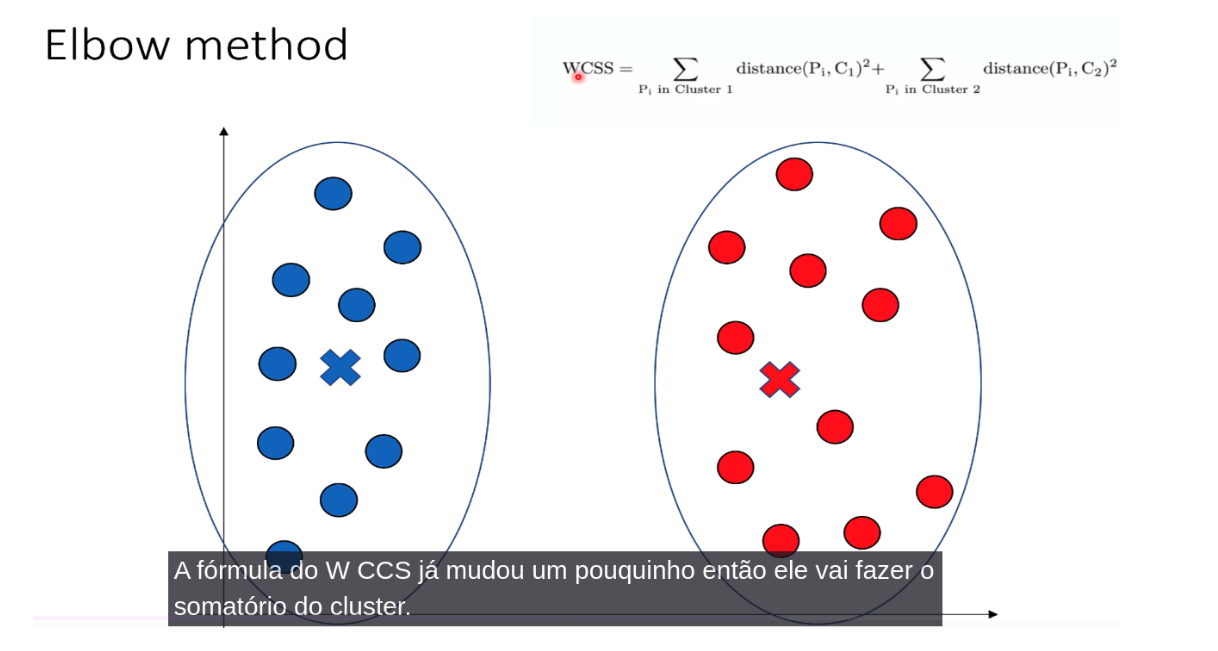

In [29]:
from sklearn.cluster import KMeans
wcss = []
# começar em 10 cluster, ideia
for i in range(1, 11):
  print(i)
  kmeans_cartao = KMeans(n_clusters=i, random_state=0) # fixar a
  kmeans_cartao.fit(X_cartao) # treinamento
  print(kmeans_cartao.inertia_)
  wcss.append(kmeans_cartao.inertia_)

1
60000.0
2
35197.83439125733
3
20128.20263562332
4
15892.249716910746
5
10708.603774943524
6
8604.404544864537
7
7684.90484613685
8
6593.001391781406
9
5669.721586002739
10
5055.083531903297


In [32]:
kmeans_cartao.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 10,
 'n_init': 'auto',
 'random_state': 0,
 'tol': 0.0001,
 'verbose': 0}

In [33]:
# importar as bibliotecas
import plotly.express as px
# concatenar os dados
import plotly.graph_objects as go
import numpy as np


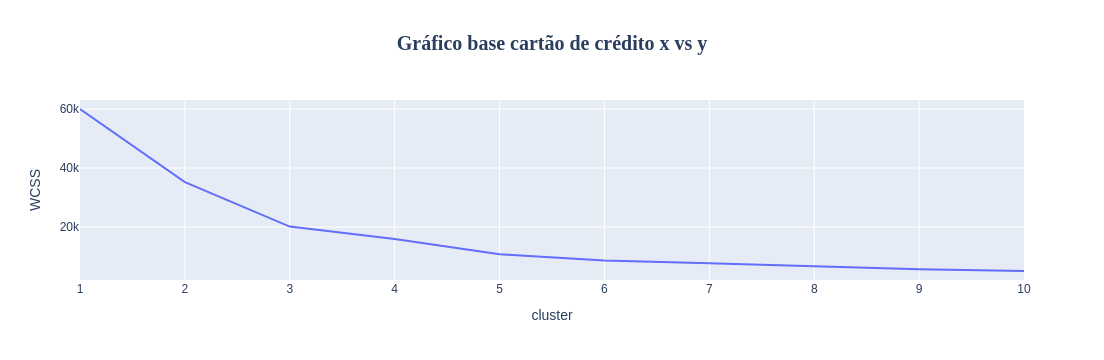

In [38]:
grafico = px.line(x = range(1,11), y = wcss, title='<b>Gráfico base cartão de crédito x vs y</b>')

# Atualiza o layout para renomear os rótulos dos eixos X e Y
grafico.update_layout(
    xaxis_title_text='cluster',
    yaxis_title_text='WCSS',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("figuras/18-6_grafico.html")
#https://plotly.com/python/interactive-html-export/

In [39]:
# de 4 para 5 não há uma queda muito grande, como de 6 para 7, é mais de 3 para 4

# agrupamento ou com 4 ou 5 cluster, se for mais cluster não haverá uma queda acentuada


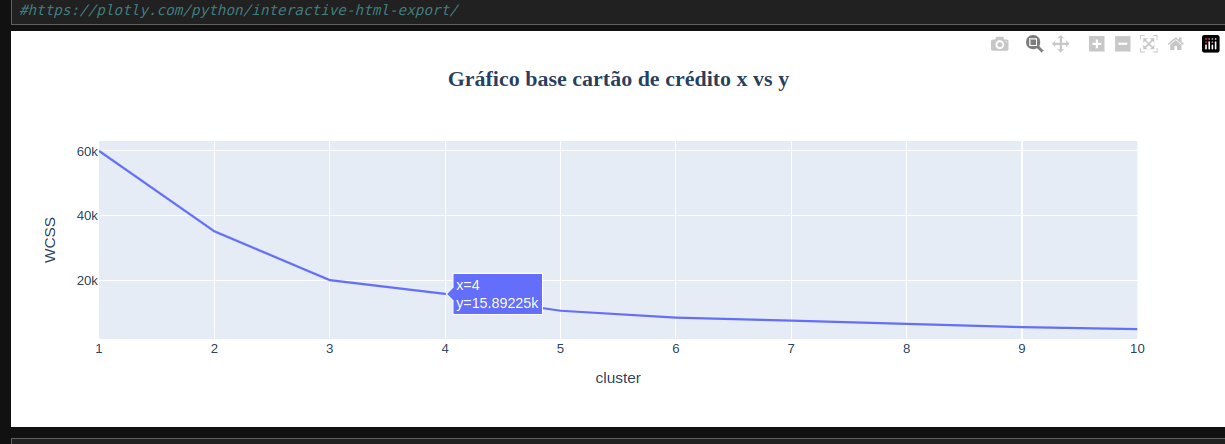

### pegar o número onde não há uma queda muito grande

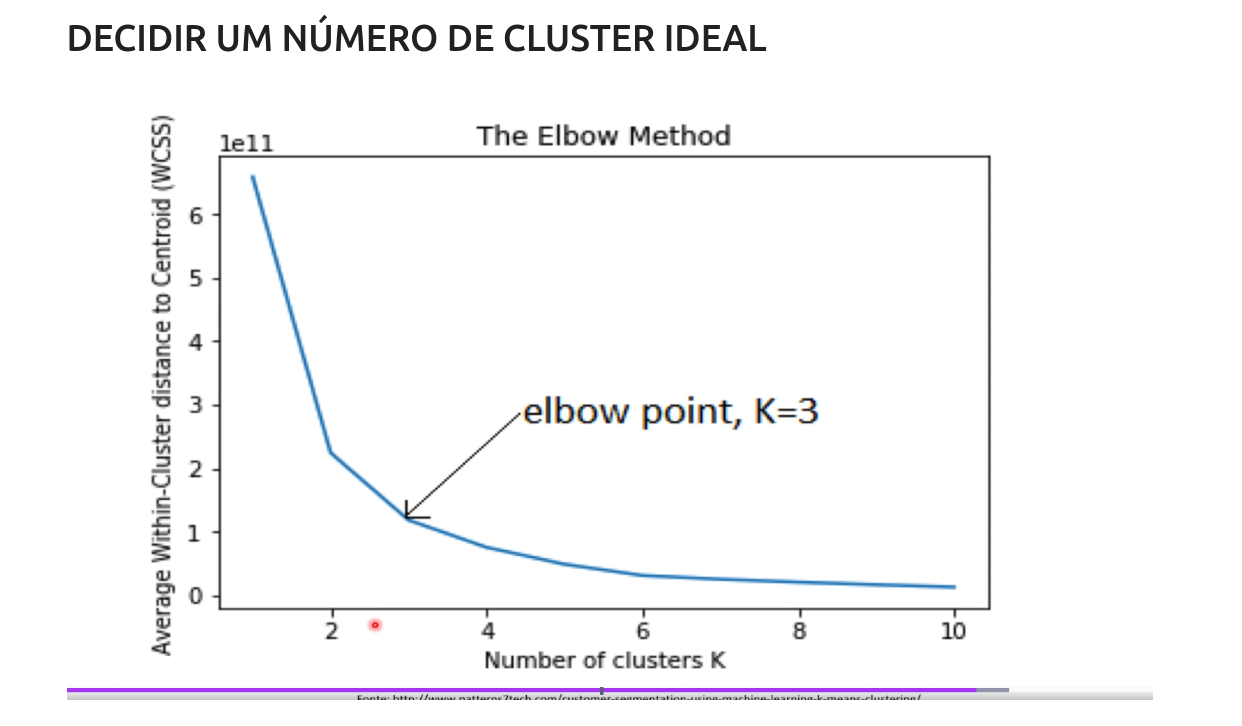

In [42]:
wcss

[60000.0,
 35197.83439125733,
 20128.20263562332,
 15892.249716910746,
 10708.603774943524,
 8604.404544864537,
 7684.90484613685,
 6593.001391781406,
 5669.721586002739,
 5055.083531903297]

In [43]:
kmeans_cartao = KMeans(n_clusters=4, random_state=0) # random_state =0 para sempre termos os mesmos resultados


In [44]:
rotulos = kmeans_cartao.fit_predict(X_cartao) # gerando os rotulos, fazendo o treinamento e já teremos os resultados

In [45]:
rotulos

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

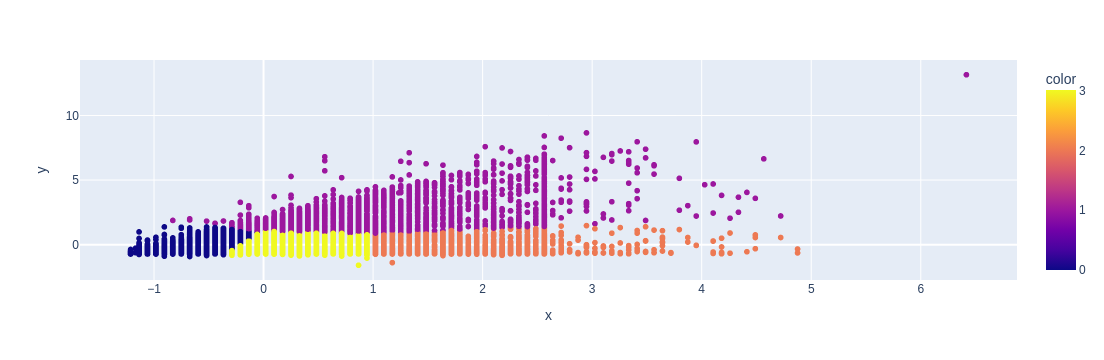

In [46]:
grafico = px.scatter(x = X_cartao[:,0], y = X_cartao[:,1], color=rotulos)
grafico.show()

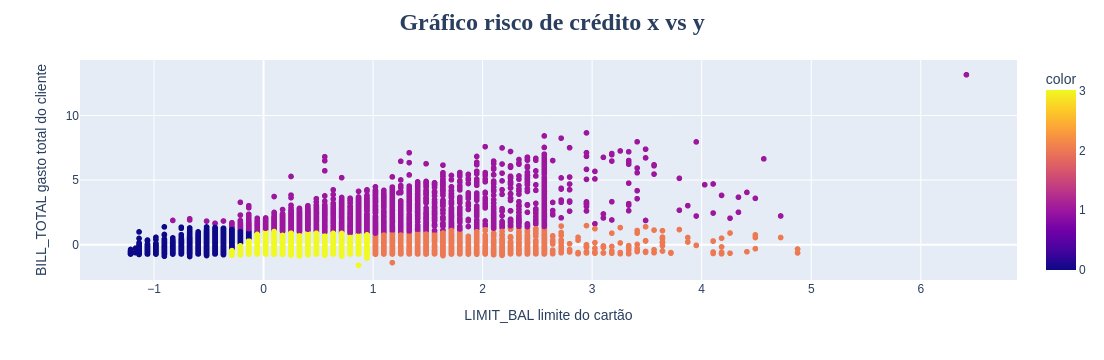

In [48]:
# x base idade e base salário
grafico = px.scatter(x = X_cartao[:,0], y = X_cartao[:,1], color=rotulos)

# Atualiza o layout para renomear os rótulos dos eixos X e Y
grafico.update_layout(
    # Defina o título aqui, no gráfico que será exibido
    title_text='<b>Gráfico risco de crédito x vs y</b>',
    xaxis_title_text='LIMIT_BAL limite do cartão',  #'BILL_TOTAL'
    yaxis_title_text='BILL_TOTAL gasto total do cliente',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)
grafico.show()
grafico.write_html("figuras/18-6_grafico2.html")


### grupo azul não usariam muito assim como parte do amarelo, não seria interessante aumentar o limite do cartão de crédito, não valeria apena aumentar. 

### interessante oferecer crédito ou aumentar o limite no roxo, que também há um outlier bem depois do limite bar acima de 6.

In [50]:
#extrair insight para as empresas, aumentar o limite. 

In [51]:
# unir a base de dados mais os rotulos
lista_clientes = np.column_stack((base_cartao, rotulos))
lista_clientes



array([[     1,  20000,      2, ...,      1,   7704,      0],
       [     2, 120000,      2, ...,      1,  17077,      0],
       [     3,  90000,      2, ...,      0, 101653,      0],
       ...,
       [ 29998,  30000,      1, ...,      1,  70496,      0],
       [ 29999,  80000,      1, ...,      1, 266611,      0],
       [ 30000,  50000,      1, ...,      1, 230874,      0]])

In [57]:
set(rotulos) # quantos grupos há criados na base de dados. Também pode renomear os rotulos.

{0, 1, 2, 3}

In [58]:
# também podemos ordenar os dados 

lista_clientes = lista_clientes[lista_clientes[:,26].argsort()]
lista_clientes

array([[     1,  20000,      2, ...,      1,   7704,      0],
       [ 16302,  20000,      2, ...,      0,  41096,      0],
       [ 16300,  10000,      2, ...,      1,  55201,      0],
       ...,
       [  6521, 230000,      2, ...,      1,  46969,      3],
       [ 16327, 200000,      2, ...,      1, 328928,      3],
       [ 19905, 210000,      2, ...,      0,   4580,      3]])

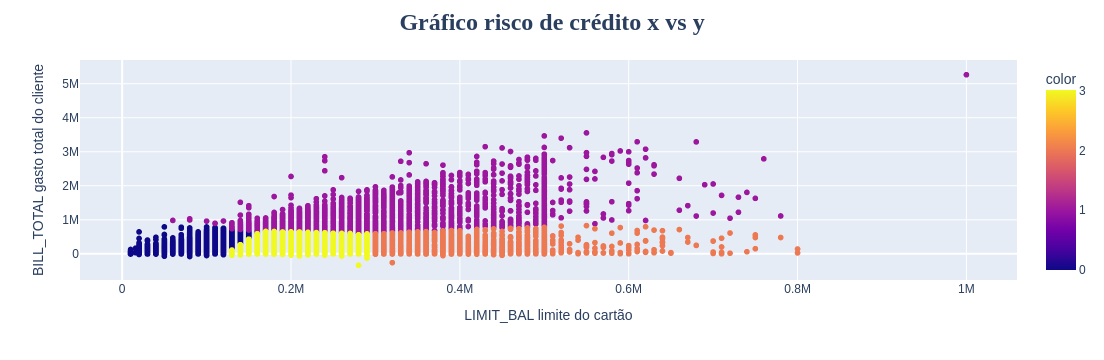

In [59]:
# x base idade e base salário
grafico = px.scatter(x = lista_clientes[:,1], y = lista_clientes[:,25], color= lista_clientes[:,26])

# Atualiza o layout para renomear os rótulos dos eixos X e Y
grafico.update_layout(
    # Defina o título aqui, no gráfico que será exibido
    title_text='<b>Gráfico risco de crédito x vs y</b>',
    xaxis_title_text='LIMIT_BAL limite do cartão',  #'BILL_TOTAL'
    yaxis_title_text='BILL_TOTAL gasto total do cliente',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)
grafico.show()
grafico.write_html("figuras/18-6_grafico3.html")